# Analyse av forurenset grunn i Agder

Denne notebooken analyserer geografiske data for forurenset grunn i Agder. 
Datasettet inneholder polygoner som representerer områder med registrert 
forurensning.

Målet med analysen er å undersøke hvordan forurenset grunn er fordelt mellom 
kommunene i Agder.

I analysen tas det inn en geojson fra geonorge som inneholder områder med forrurenset grunn, og en annen geojson som laster iinn kommunegrenser i norge, men som blir avgrenset til agder fylke.

Analysen inkluderer:

Introduksjon

Import av biblioteker

Innlesing av datasett

Kontroll av koordinatsystem

Filtrering til Agder

Visualisering av data

Romlig join

Arealberegning

Aggregering per kommune

Bufferanalyse

Overlayanalyse

DuckDB analyse

Rasteranalyse

Konklusjon

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## Lese inn datasett med forurenset grunn

Datasettet inneholder polygoner som representerer områder med registrert 
forurensning i Agder. Dataene kommer fra Miljødirektoratets database for 
grunnforurensning.

In [2]:
forurensning = gpd.read_file("forrurenset.json")

forurensning.head()

,identifikasjon_lokalId,identifikasjon_navnerom,datafangstdato,faktaark,objekttype,arealNøyaktighet,arealTotalt,arealbruk,forvaltningsmyndighet,forvaltningsmyndighetType,...,opphav,påvirkningsgrad,prosessStatus,saksnummer,status,tilstandsklasse,vedtak,virksomhetNavn,kommune,geometry
0,3285-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,middels,1777,sentrumsområder,42,statsforvalteren,...,Miljødirektoratets grunnforurensningsdatabase,akseptabelForurensning,avsluttet,2019/5842-30,Godkjent,dårlig,"påleggUndersøkelse/,/,påleggUndersøkelse/,påle...","Byglandsfjord Dampsag (tidligere),Byglandsfjor...",[4220],"POLYGON ((7.80416 58.66851, 7.80401 58.66869, ..."
1,3310-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,middels,11853,industriOgTrafikk,42,statsforvalteren,...,Miljødirektoratets grunnforurensningsdatabase,akseptabelForurensning,avsluttet,"1997/878, 2008/8171, 2019/5842",Godkjent,moderat,"tillatelse/,godkjentByggeGrave/,delegeringMynd...","BJARNE JOHANSEN SKRAPHANDEL (tidligere),BJARNE...",[4204],"POLYGON ((7.94852 58.16361, 7.94899 58.16369, ..."
2,3391-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,middels,33822,industriOgTrafikk,42,statsforvalteren,...,Miljødirektoratets grunnforurensningsdatabase,akseptabelForurensning,overvåking,2016/1400,GodkjentNyedataUnderRegistrering,sværtDårlig,"påleggTiltaksplan/,/,påleggTiltaksplan/",KRISTIANSAND KOMMUNE TEKNISK SEKTOR,[4204],"POLYGON ((8.03307 58.15452, 8.03306 58.15452, ..."
3,3462-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,høy,4740,industriOgTrafikk,42,statsforvalteren,...,Miljødirektoratets grunnforurensningsdatabase,akseptabelForurensning,undersøkelseGjennomført,2007/1204,Godkjent,dårlig,påleggUndersøkelse/,"SIMEK AS,SICOAT AS (nedlagt)",[4207],"POLYGON ((6.65497 58.28473, 6.65497 58.28473, ..."
4,15266-B,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,,650,sentrumsområder,4203,kommune,...,Miljødirektoratets grunnforurensningsdatabase,akseptabelForurensning,tiltakGjennomført,20/6768,Godkjent,moderat,"godkjentByggeGrave/,godkjentByggeGrave/",UNO-X NORGE AS,[4203],"POLYGON ((8.75697 58.47948, 8.75677 58.47949, ..."


## Kontroll av koordinatsystem

Det er viktig å kontrollere koordinatsystemet til datasettene før romlige 
analyser gjennomføres.

In [3]:
forurensning.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Lese inn kommunedata

Dette datasettet inneholder polygoner for kommunene i Norge. 
Kommunedataene brukes til å analysere hvordan forurenset grunn 
er fordelt geografisk mellom kommuner.

In [4]:
kommuner = gpd.read_file("kommuner.geojson")

kommuner.head()

,kommunenavn,kommunenummer,geometry
0,Aarborte,1826,"POLYGON ((13.642 65.738, 13.754 65.776, 14.076..."
1,Åfjord,5058,"POLYGON ((9.614 64.075, 9.725 64.274, 9.7 64.3..."
2,Ål,3043,"POLYGON ((7.775 60.867, 7.879 60.924, 8.041 60..."
3,Ålesund,1507,"POLYGON ((5.641 62.812, 6.338 63.091, 6.707 62..."
4,Alstahaug,1820,"POLYGON ((12.24 65.695, 12.071 65.867, 12.228 ..."


## Filtrering av kommuner i Agder

Kommuner i Agder identifiseres ved at kommunenummer starter med 42. 
Datasettet filtreres derfor slik at kun kommuner i Agder inkluderes 
i analysen.

In [5]:
kommuner_agder = kommuner[kommuner["kommunenummer"].astype(str).str.startswith("42")]

kommuner_agder.head()

,kommunenavn,kommunenummer,geometry
8,Åmli,4217,"POLYGON ((7.986 58.707, 8.017 58.847, 7.961 58..."
13,Arendal,4203,"POLYGON ((9.067 58.25, 8.707 58.404, 8.558 58...."
15,Åseral,4224,"POLYGON ((7.159 58.671, 7.162 58.82, 7.459 58...."
36,Birkenes,4216,"POLYGON ((7.933 58.557, 8.098 58.569, 8.106 58..."
45,Bygland,4220,"POLYGON ((7.033 58.821, 7.165 58.941, 7.821 59..."


## Visualisering av datasett

Her visualiseres kommunene i Agder sammen med områdene med 
registrert forurenset grunn.

(Små røde prikker)

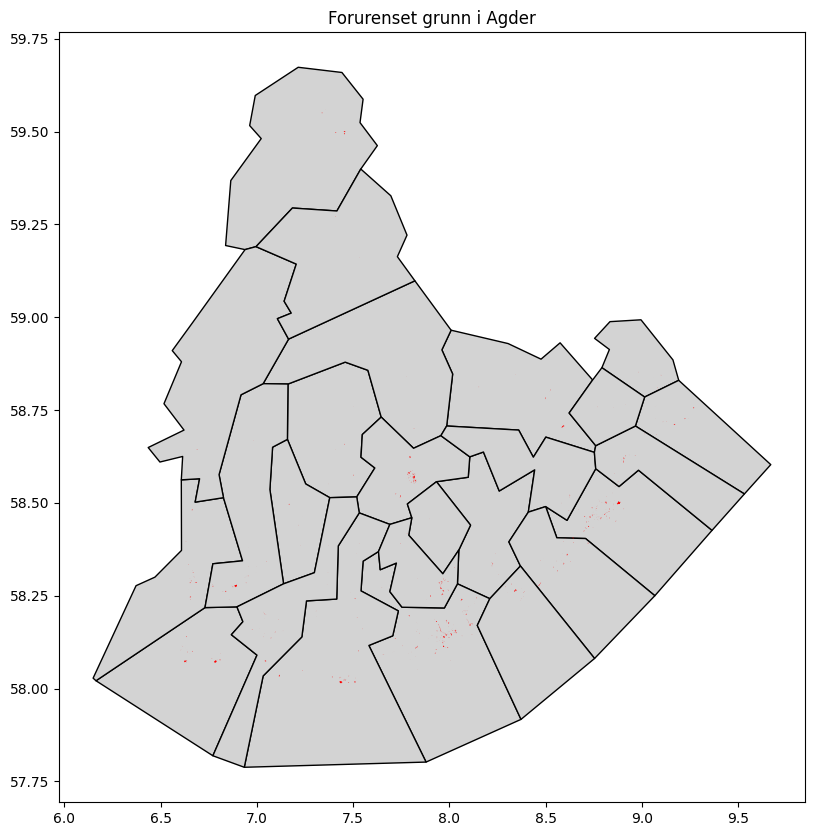

In [6]:
fig, ax = plt.subplots(figsize=(10,10))

kommuner_agder.plot(ax=ax, color="lightgrey", edgecolor="black")
forurensning.plot(ax=ax, color="red")

plt.title("Forurenset grunn i Agder")
plt.show()

## Transformasjon av koordinatsystem

For å kunne beregne areal korrekt må datasettene bruke et projisert 
koordinatsystem med meter som enhet. Datasettene transformeres derfor 
til UTM sone 33 (EPSG:25833).

In [7]:
forurensning = forurensning.to_crs(25833)
kommuner_agder = kommuner_agder.to_crs(25833)

## Romlig kobling mellom forurensning og kommuner

For å analysere forurensning per kommune utføres en romlig join. 
Dette kobler hvert forurenset område til kommunen det ligger innenfor.

In [8]:
forurensning_kommune = gpd.sjoin(
    forurensning,
    kommuner_agder,
    how="left",
    predicate="intersects"
)

forurensning_kommune.head()

,identifikasjon_lokalId,identifikasjon_navnerom,datafangstdato,faktaark,objekttype,arealNøyaktighet,arealTotalt,arealbruk,forvaltningsmyndighet,forvaltningsmyndighetType,...,saksnummer,status,tilstandsklasse,vedtak,virksomhetNavn,kommune,geometry,index_right,kommunenavn,kommunenummer
0,3285-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,middels,1777,sentrumsområder,42,statsforvalteren,...,2019/5842-30,Godkjent,dårlig,"påleggUndersøkelse/,/,påleggUndersøkelse/,påle...","Byglandsfjord Dampsag (tidligere),Byglandsfjor...",[4220],"POLYGON ((83121.314 6525547.951, 83115.149 652...",45,Bygland,4220
1,3310-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,middels,11853,industriOgTrafikk,42,statsforvalteren,...,"1997/878, 2008/8171, 2019/5842",Godkjent,moderat,"tillatelse/,godkjentByggeGrave/,delegeringMynd...","BJARNE JOHANSEN SKRAPHANDEL (tidligere),BJARNE...",[4204],"POLYGON ((85561.794 6468634.554, 85590.071 646...",148,Kristiansand,4204
2,3391-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,middels,33822,industriOgTrafikk,42,statsforvalteren,...,2016/1400,GodkjentNyedataUnderRegistrering,sværtDårlig,"påleggTiltaksplan/,/,påleggTiltaksplan/",KRISTIANSAND KOMMUNE TEKNISK SEKTOR,[4204],"POLYGON ((90414.838 6467107.356, 90414.321 646...",148,Kristiansand,4204
3,3462-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,høy,4740,industriOgTrafikk,42,statsforvalteren,...,2007/1204,Godkjent,dårlig,påleggUndersøkelse/,"SIMEK AS,SICOAT AS (nedlagt)",[4207],"POLYGON ((11431.668 6490760.945, 11431.693 649...",75,Flekkefjord,4207
4,15266-B,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,,650,sentrumsområder,4203,kommune,...,20/6768,Godkjent,moderat,"godkjentByggeGrave/,godkjentByggeGrave/",UNO-X NORGE AS,[4203],"POLYGON ((136252.862 6499013.718, 136241.121 6...",13,Arendal,4203


## Beregning av areal

Arealet til hvert forurenset område beregnes i kvadratmeter basert 
på polygongeometrien.

In [9]:
forurensning_kommune["areal_m2"] = forurensning_kommune.geometry.area

## Aggregering av forurenset areal per kommune

For å analysere fordelingen av forurensning summeres arealet av 
forurensede områder innenfor hver kommune.

In [10]:
areal_per_kommune = (
    forurensning_kommune
    .groupby("kommunenavn")["areal_m2"]
    .sum()
    .reset_index()
)

areal_per_kommune

,kommunenavn,areal_m2
0,Arendal,2.482093e+06
1,Birkenes,7.703128e+04
2,Bygland,1.826125e+04
3,Bykle,2.782625e+05
4,Evje og Hornnes,1.315019e+06
5,Farsund,8.495512e+05
6,Flekkefjord,3.262853e+05
7,Froland,5.004111e+04
8,Gjerstad,3.497461e+04
9,Grimstad,5.039903e+05


## Visualisering av forurenset areal per kommune

Resultatet kobles tilbake til kommunedataene slik at det kan 
visualiseres på kart.

In [14]:
kommuner_resultat = kommuner_agder.merge(
    areal_per_kommune,
    on="kommunenavn",
    how="left"
)

kommuner_resultat["areal_m2"] = kommuner_resultat["areal_m2"].fillna(0)

## Kart over forurenset areal i Agder

Kartet viser hvor mye forurenset grunn som finnes i hver kommune.

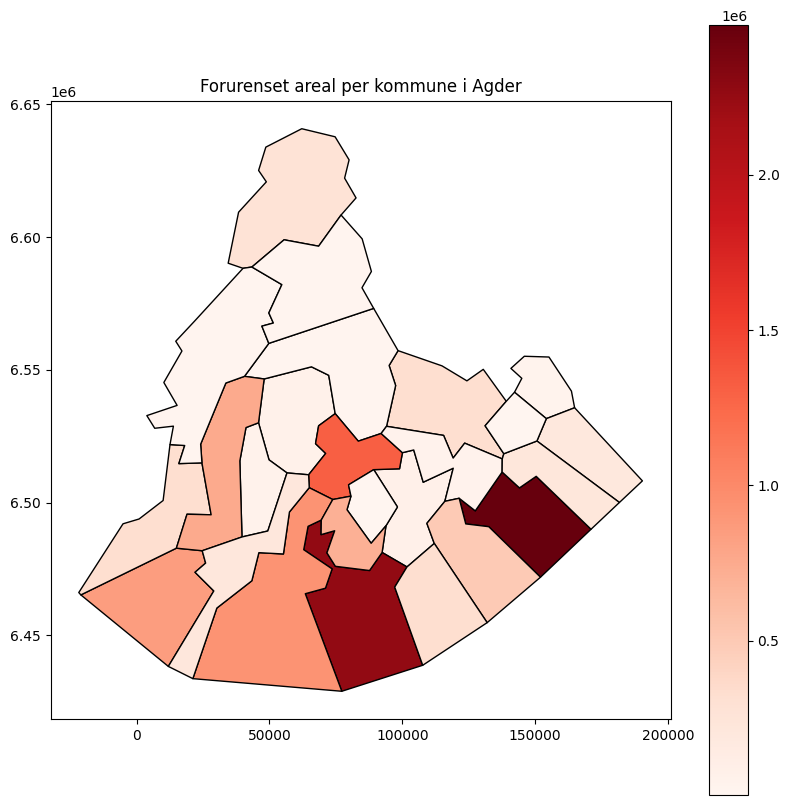

In [15]:
fig, ax = plt.subplots(figsize=(10,10))

kommuner_resultat.plot(
    column="areal_m2",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    ax=ax
)

plt.title("Forurenset areal per kommune i Agder")
plt.show()

## Bufferanalyse rundt forurenset grunn

For å undersøke hvilke områder som ligger i nærheten av forurenset grunn, 
opprettes en buffersone på 500 meter rundt hvert forurenset polygon. 
Dette gjør det mulig å analysere nærliggende påvirkningsområder.

In [16]:
forurensning_buffer = forurensning.copy()
forurensning_buffer["geometry"] = forurensning_buffer.geometry.buffer(500)

forurensning_buffer.head()

,identifikasjon_lokalId,identifikasjon_navnerom,datafangstdato,faktaark,objekttype,arealNøyaktighet,arealTotalt,arealbruk,forvaltningsmyndighet,forvaltningsmyndighetType,...,opphav,påvirkningsgrad,prosessStatus,saksnummer,status,tilstandsklasse,vedtak,virksomhetNavn,kommune,geometry
0,3285-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,middels,1777,sentrumsområder,42,statsforvalteren,...,Miljødirektoratets grunnforurensningsdatabase,akseptabelForurensning,avsluttet,2019/5842-30,Godkjent,dårlig,"påleggUndersøkelse/,/,påleggUndersøkelse/,påle...","Byglandsfjord Dampsag (tidligere),Byglandsfjor...",[4220],"POLYGON ((83175.353 6525050.879, 83136.007 652..."
1,3310-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,middels,11853,industriOgTrafikk,42,statsforvalteren,...,Miljødirektoratets grunnforurensningsdatabase,akseptabelForurensning,avsluttet,"1997/878, 2008/8171, 2019/5842",Godkjent,moderat,"tillatelse/,godkjentByggeGrave/,delegeringMynd...","BJARNE JOHANSEN SKRAPHANDEL (tidligere),BJARNE...",[4204],"POLYGON ((85277.878 6468223.583, 85277.805 646..."
2,3391-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,middels,33822,industriOgTrafikk,42,statsforvalteren,...,Miljødirektoratets grunnforurensningsdatabase,akseptabelForurensning,overvåking,2016/1400,GodkjentNyedataUnderRegistrering,sværtDårlig,"påleggTiltaksplan/,/,påleggTiltaksplan/",KRISTIANSAND KOMMUNE TEKNISK SEKTOR,[4204],"POLYGON ((89670.317 6467278.897, 89676.868 646..."
3,3462-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,høy,4740,industriOgTrafikk,42,statsforvalteren,...,Miljødirektoratets grunnforurensningsdatabase,akseptabelForurensning,undersøkelseGjennomført,2007/1204,Godkjent,dårlig,påleggUndersøkelse/,"SIMEK AS,SICOAT AS (nedlagt)",[4207],"POLYGON ((11617.418 6490297.08, 11601.292 6490..."
4,15266-B,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,,650,sentrumsområder,4203,kommune,...,Miljødirektoratets grunnforurensningsdatabase,akseptabelForurensning,tiltakGjennomført,20/6768,Godkjent,moderat,"godkjentByggeGrave/,godkjentByggeGrave/",UNO-X NORGE AS,[4203],"POLYGON ((136743.608 6498917.965, 136742.285 6..."


## Visualisering av buffersoner

Kartet viser forurenset grunn og en buffersone på 500 meter rundt hvert område. 
Dette gir et visuelt bilde av hvilke områder som potensielt kan være påvirket 
i nærområdet.

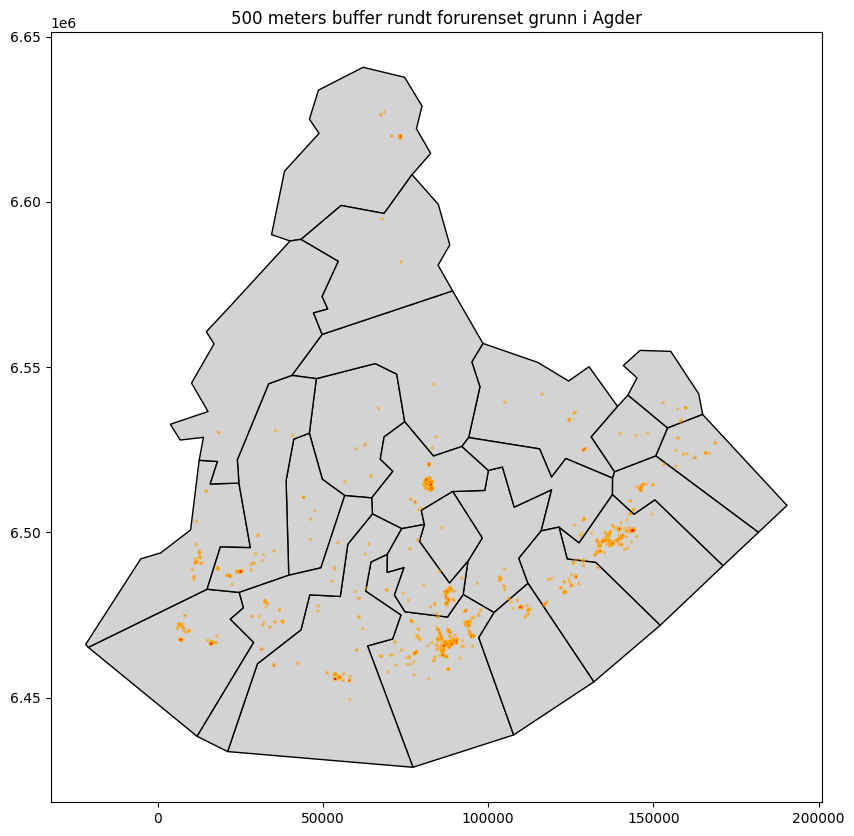

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

kommuner_agder.plot(ax=ax, color="lightgrey", edgecolor="black")
forurensning_buffer.plot(ax=ax, color="orange", alpha=0.5)
forurensning.plot(ax=ax, color="red")

plt.title("500 meters buffer rundt forurenset grunn i Agder")
plt.show()

## Overlayanalyse mellom buffersoner og kommuner

For å undersøke hvilke deler av kommunene som ligger innenfor 500 meter fra 
forurenset grunn, brukes en overlay-operasjon. Her benyttes intersection, 
som finner skjæringsområdet mellom buffersoner og kommunegrenser.

In [18]:
kommune_buffer_intersection = gpd.overlay(
    kommuner_agder,
    forurensning_buffer,
    how="intersection"
)

kommune_buffer_intersection.head()

,kommunenavn,kommunenummer,identifikasjon_lokalId,identifikasjon_navnerom,datafangstdato,faktaark,objekttype,arealNøyaktighet,arealTotalt,arealbruk,...,opphav,påvirkningsgrad,prosessStatus,saksnummer,status,tilstandsklasse,vedtak,virksomhetNavn,kommune,geometry
0,Åmli,4217,3267-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,høy,234935,uavklart,...,Miljødirektoratets grunnforurensningsdatabase,ikkeAkseptabelForurensning,undersøkelseGjennomført,SFT/2002/8-20,Godkjent,,påleggUndersøkelse/,Bergene Holm,[4217],"POLYGON ((128007.077 6524699.899, 128007.128 6..."
1,Åmli,4217,3268-A,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,høy,5184,INFOmråde,...,Miljødirektoratets grunnforurensningsdatabase,ukjentPåvirkning,uavklart,"2009/3982, 2019/5842",Godkjent,,NaN,NIDARÅ TRELAST,[4217],"POLYGON ((129008.99 6524984.813, 128979.257 65..."
2,Åmli,4217,3263-B,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,,5880,INFOmråde,...,Miljødirektoratets grunnforurensningsdatabase,ukjentPåvirkning,uavklart,2009/3982-20,Godkjent,,tillatelse/,ÅMLI KOMMUNE SAMFUNNSAVDELINGA,[4217],"POLYGON ((125172.343 6534090.001, 125155.807 6..."
3,Åmli,4217,3265-B,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,,9828,INFOmråde,...,Miljødirektoratets grunnforurensningsdatabase,ukjentPåvirkning,uavklart,2009/3982-20,Godkjent,,tillatelse/,ÅMLI KOMMUNE SAMFUNNSAVDELINGA,[4217],"POLYGON ((104442.643 6539168.85, 104425.435 65..."
4,Åmli,4217,3266-B,https://www.miljodirektoratet.no/forurensning,None,https://grunnforurensning.miljodirektoratet.no...,ForurensetGrunn,,4302,INFOmråde,...,Miljødirektoratets grunnforurensningsdatabase,ukjentPåvirkning,uavklart,2009/3982-20,Godkjent,,tillatelse/,ÅMLI KOMMUNE SAMFUNNSAVDELINGA,[4217],"POLYGON ((116762.659 6541621.359, 116737.331 6..."


## Beregning av areal innenfor buffersonene

Arealet av skjæringsområdene beregnes for å analysere hvor store deler av 
kommunene som ligger innenfor buffersonene rundt forurenset grunn.

In [19]:
kommune_buffer_intersection["buffer_areal_m2"] = kommune_buffer_intersection.geometry.area

## Aggregering av bufferareal per kommune

Her summeres arealet innenfor buffersonene for hver kommune. 
Dette viser hvilke kommuner som har størst areal innenfor 500 meter fra 
forurenset grunn.

In [20]:
buffer_per_kommune = (
    kommune_buffer_intersection
    .groupby("kommunenavn")["buffer_areal_m2"]
    .sum()
    .reset_index()
)

buffer_per_kommune

,kommunenavn,buffer_areal_m2
0,Arendal,1.381312e+08
1,Birkenes,1.098616e+07
2,Bygland,2.788418e+06
3,Bykle,9.262790e+06
4,Evje og Hornnes,6.765856e+07
5,Farsund,3.673193e+07
6,Flekkefjord,2.205271e+07
7,Froland,5.846596e+06
8,Gjerstad,6.332143e+06
9,Grimstad,3.686032e+07


## Kart over areal innenfor buffersoner per kommune

Kartet viser hvor store arealer i hver kommune som ligger innenfor 
500 meter fra registrert forurenset grunn.

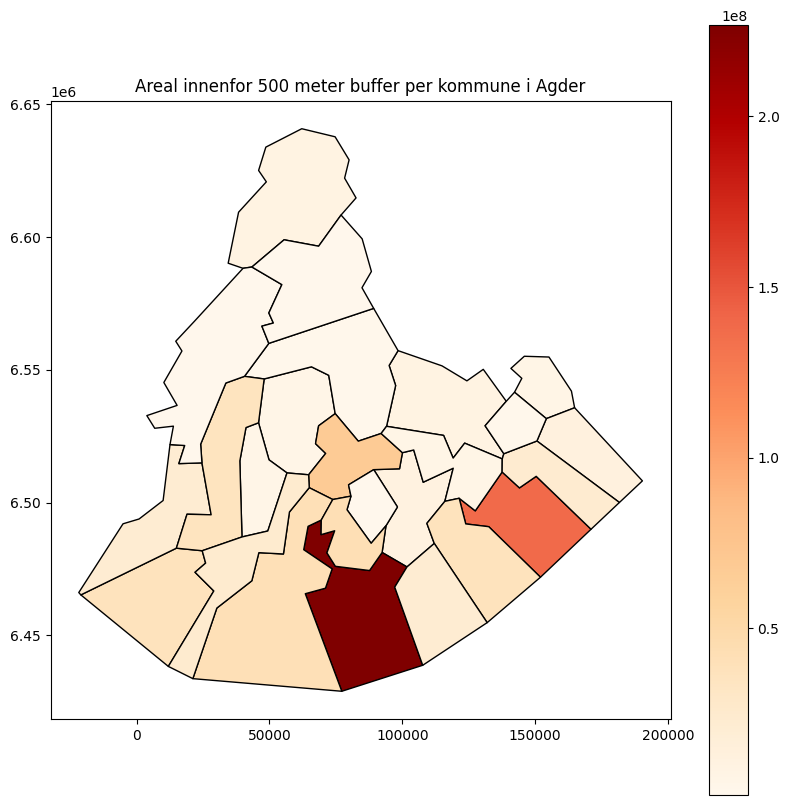

In [21]:
kommuner_buffer_resultat = kommuner_agder.merge(
    buffer_per_kommune,
    on="kommunenavn",
    how="left"
)

kommuner_buffer_resultat["buffer_areal_m2"] = kommuner_buffer_resultat["buffer_areal_m2"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 10))

kommuner_buffer_resultat.plot(
    column="buffer_areal_m2",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

plt.title("Areal innenfor 500 meter buffer per kommune i Agder")
plt.show()

## Analyse med DuckDB

For å vise bruk av SQL i arbeidsflyten brukes DuckDB. 
Resultattabellen med forurenset areal per kommune registreres i DuckDB, 
og det kjøres en SQL-spørring for å finne kommunene med størst forurenset areal.

In [22]:
import duckdb

ModuleNotFoundError: No module named 'duckdb'

In [23]:
!pip install duckdb

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/12.8 MB 11.9 MB/s eta 0:00:01
   ------------- -------------------------- 4.5/12.8 MB 12.6 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.8 MB 12.6 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.8 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.8 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 12.4 MB/s  0:00:01



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import duckdb

In [25]:
con = duckdb.connect()
con.register("areal_per_kommune", areal_per_kommune)

duckdb_resultat = con.execute("""
    SELECT kommunenavn, areal_m2
    FROM areal_per_kommune
    ORDER BY areal_m2 DESC
""").df()

duckdb_resultat

,kommunenavn,areal_m2
0,Arendal,2.482093e+06
1,Kristiansand,2.268364e+06
2,Evje og Hornnes,1.315019e+06
3,Lindesnes,9.315425e+05
4,Farsund,8.495512e+05
5,Kvinesdal,7.512939e+05
6,Vennesla,7.094105e+05
7,Grimstad,5.039903e+05
8,Åmli,3.313096e+05
9,Lillesand,3.272052e+05


## De kommunene med størst forurenset areal

SQL-spørringen rangerer kommunene etter totalt forurenset areal og 
viser hvilke kommuner som har størst registrert forurenset grunn.

In [26]:
duckdb_resultat.head(10)

,kommunenavn,areal_m2
0,Arendal,2.482093e+06
1,Kristiansand,2.268364e+06
2,Evje og Hornnes,1.315019e+06
3,Lindesnes,9.315425e+05
4,Farsund,8.495512e+05
5,Kvinesdal,7.512939e+05
6,Vennesla,7.094105e+05
7,Grimstad,5.039903e+05
8,Åmli,3.313096e+05
9,Lillesand,3.272052e+05


## Oppsummering av vektoranalysen

Analysen viser at forurenset grunn i Agder er ujevnt fordelt mellom kommunene. 
Ved hjelp av romlig join og aggregering ble totalt forurenset areal beregnet 
per kommune. Bufferanalysen viste hvilke områder som ligger innenfor 500 meter 
fra forurenset grunn, og overlayanalysen gjorde det mulig å beregne hvor store 
deler av kommunene som ligger innenfor disse buffersonene.

Bruk av GeoPandas gjorde det mulig å utføre romlige analyser direkte i Python, 
mens DuckDB ble brukt til å analysere resultatene videre med SQL.

## Rasteranalyse av terreng

I denne delen brukes rasterdata (DEM – Digital Elevation Model) til å analysere terreng. 
Analysen viser hvordan helning kan beregnes fra høydedata og hvordan bratte områder kan 
identifiseres og konverteres til vektordata.

Rasteranalysen gjennomføres ved hjelp av GDAL-kommandolinjeverktøy.

### 1. Nedlasting av høydedata (DEM)

Først lastes en digital høydemodell (DEM) ned for ønsket område i Agder. 
DEM-data kan lastes ned fra for eksempel GeoNorge.

DEM-rasteret inneholder høydeverdier for hver celle i rasteret.

### 2. Beregning av helningskart (slope)

Helning kan beregnes fra DEM ved hjelp av GDAL-verktøyet `gdaldem`.

Kommando:

```bash
gdaldem slope dem.tif slope.tif

### 3. Filtrering av områder med helning større enn 30 grader

For å identifisere bratte områder kan rasteret filtreres slik at bare
områder med helning over 30 grader beholdes.

Eksempelkommando:

```bash
gdal_calc.py -A slope.tif --outfile=slope_over_30.tif --calc="A*(A>30)"
```

Denne kommandoen lager et nytt raster hvor bare celler med helning større
enn 30 grader beholdes.


### 4. Konvertering fra raster til vektordata (polygonize)

Rasteret kan konverteres til polygoner slik at bratte områder kan
analyseres videre som vektordata.

Kommando:

```bash
gdal_polygonize.py slope_over_30.tif -f "GeoJSON" slope_over_30.geojson
```

Dette lager et polygonlag som representerer områder med bratt terreng.


### 5. Hillshade visualisering

Hillshade brukes for å visualisere terreng ved å simulere lys og skygge
på overflaten.

To hillshade-raster kan lages med forskjellige lysparametere.

Eksempel 1:

```bash
gdaldem hillshade dem.tif hillshade1.tif -az 315 -alt 45
```

Eksempel 2:

```bash
gdaldem hillshade dem.tif hillshade2.tif -az 180 -alt 60
```

Ved å endre lysretning og høydevinkel kan terrengvisualiseringen fremheve
ulike landskapsformer.


## Konklusjon

Denne notebooken demonstrerer en arbeidsflyt for romlig analyse i Python.
Geografiske datasett ble lest inn, filtrert og analysert ved hjelp av GeoPandas.

Romlige operasjoner som buffer, overlay og romlig aggregering ble brukt for å
analysere forurenset grunn i Agder. Resultatene ble visualisert på kart og
videre analysert ved hjelp av SQL i DuckDB.

Rasterdelen viser hvordan høydedata kan brukes til å beregne helning,
identifisere bratte områder og lage hillshade-visualiseringer.
